# 😷 Face Mask Detection System

A deep learning-based computer vision system designed to automatically detect whether a person is wearing a face mask or not. This project helps promote public health safety by enabling real-time mask compliance monitoring in public spaces.

## 🎯 Objective

The primary goal of this system is to identify and classify faces into two categories:

* **With Mask**
* **Without Mask**

Using image processing and deep learning techniques, the system can accurately analyze facial images and determine mask usage in real time.

## 👨‍💻 Developers

* **Saleh Muhammad Mangrio**
* **Kelash Kumar**
* **Bheesham Kumar**


## Step 1: Importing all necessary Packages 

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

## Step 2: Paths 

In [3]:
BASE_DIR = '/kaggle/input/datasets/ashishjangra27/face-mask-12k-images-dataset/Face Mask Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
VAL_DIR   = os.path.join(BASE_DIR, 'Validation')
TEST_DIR  = os.path.join(BASE_DIR, 'Test')

IMG_SIZE = 128
BATCH_SIZE = 64

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Step 3 : Data Augmentation

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),  
    batch_size=64,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    class_mode='binary',
    shuffle=False
)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.


## Step 4 : Transfer Learning 

In [6]:
model = Sequential([
    
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Block 4
    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')     
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,271,873 (20.11 MB)

 Trainable params: 5,271,873 (20.11 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 : CallBack and Model Training

In [8]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=8, 
        restore_best_weights=True, 
        verbose=1
    ),
    
    ModelCheckpoint(
        'best_face_mask_model.h5', 
        monitor='val_accuracy', 
        save_best_only=True, 
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=4, 
        min_lr=1e-6, 
        verbose=1
    )
]

#  Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9259 - loss: 0.2103
Epoch 1: val_accuracy improved from -inf to 0.97125, saving model to best_face_mask_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 535ms/step - accuracy: 0.9259 - loss: 0.2103 - val_accuracy: 0.9712 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9436 - loss: 0.1652
Epoch 2: val_accuracy did not improve from 0.97125
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 391ms/step - accuracy: 0.9436 - loss: 0.1652 - val_accuracy: 0.9588 - val_loss: 0.1288 - learning_rate: 0.0010
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9488 - loss: 0.1602
Epoch 3: val_accuracy did not improve from 0.97125
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - accuracy: 0.9488 - loss: 0.1603 - val_accuracy: 0.9650 - val_loss: 0.1114 - learning_rate: 0.0010
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9527 - loss: 0.1347
Epoch 4: val_accuracy improved from 0.97125 to 0.97875, saving model to best_face_mask_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - accuracy: 0.9527 - loss: 0.1347 - val_accuracy: 0.9787 - val_loss: 0.0776 - learning_rate: 0.0010
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9625 - loss: 0.1190
Epoch 5: val_accuracy did not improve from 0.97875
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - accuracy: 0.9624 - loss: 0.1190 - val_accuracy: 0.9737 - val_loss: 0.0730 - learning_rate: 0.0010
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9558 - loss: 0.1323
Epoch 6: val_accuracy did not improve from 0.97875
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - accuracy: 0.9559 - loss: 0.1323 - val_accuracy: 0.9750 - val_loss: 0.0643 - learning_rate: 0.0010
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9672 - loss: 0.1014
Epoch 7: val_accuracy improved from 0.97875 to 0.98250, saving model to best_face_mask_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - accuracy: 0.9672 - loss: 0.1014 - val_accuracy: 0.9825 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9690 - loss: 0.0979
Epoch 8: val_accuracy improved from 0.98250 to 0.98500, saving model to best_face_mask_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - accuracy: 0.9690 - loss: 0.0979 - val_accuracy: 0.9850 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9706 - loss: 0.0833
Epoch 9: val_accuracy did not improve from 0.98500
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - accuracy: 0.9706 - loss: 0.0833 - val_accuracy: 0.9812 - val_loss: 0.0602 - learning_rate: 0.0010
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9694 - loss: 0.0925
Epoch 10: val_accuracy did not improve from 0.98500
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - accuracy: 0.9694 - loss: 0.0924 - val_accuracy: 0.9725 - val_loss: 0.0754 - learning_rate: 0.0010
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9666 - loss: 0.0999
Epoch 11: val_accuracy improved from 0.98500 to 0.99000, saving model to best_face_mask_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 385ms/step - accuracy: 0.9666 - loss: 0.0998 - val_accuracy: 0.9900 - val_loss: 0.0296 - learning_rate: 0.0010
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.9771 - loss: 0.0688
Epoch 12: val_accuracy improved from 0.99000 to 0.99125, saving model to best_face_mask_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 388ms/step - accuracy: 0.9771 - loss: 0.0689 - val_accuracy: 0.9912 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 13/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9797 - loss: 0.0593
Epoch 13: val_accuracy improved from 0.99125 to 0.99250, saving model to best_face_mask_model.h5


157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - accuracy: 0.9797 - loss: 0.0593 - val_accuracy: 0.9925 - val_loss: 0.0218 - learning_rate: 0.0010
Epoch 14/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9821 - loss: 0.0551
Epoch 14: val_accuracy did not improve from 0.99250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step - accuracy: 0.9821 - loss: 0.0551 - val_accuracy: 0.9887 - val_loss: 0.0329 - learning_rate: 0.0010
Epoch 15/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9803 - loss: 0.0559
Epoch 15: val_accuracy did not improve from 0.99250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - accuracy: 0.9803 - loss: 0.0559 - val_accuracy: 0.9925 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 16/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.9801 - loss: 0.0581
Epoch 16: val_accuracy did not improve from 0.99250
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 382ms/step - accuracy: 0.9801 - loss: 0.0581 - val_accuracy: 0.9862 - val_loss: 0.0324 - learning_rate: 0.0010
E

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step - accuracy: 0.9847 - loss: 0.0466 - val_accuracy: 0.9962 - val_loss: 0.0129 - learning_rate: 5.0000e-04
Epoch 19/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9890 - loss: 0.0356
Epoch 19: val_accuracy did not improve from 0.99625
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 385ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9937 - val_loss: 0.0182 - learning_rate: 5.0000e-04
Epoch 20/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9888 - loss: 0.0313
Epoch 20: val_accuracy did not improve from 0.99625
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 387ms/step - accuracy: 0.9888 - loss: 0.0313 - val_accuracy: 0.9950 - val_loss: 0.0110 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 20.


In [9]:
model.save("face_mask_detect.h5")
print("✅ Model saved successfully as 'face_mask_detect.h5'")

model.save("face_mask_detect.keras")
print("Model saved as 'face_mask_detect.keras'")

✅ Model saved successfully as 'face_mask_detect.h5'
Model saved as 'face_mask_detect.keras'


## Step 7 : Evalution and Test

In [10]:
print("Evaluating model on test set...")

test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("="*60)

# Show prediction summary
print(f"Test samples evaluated: {test_generator.samples}")
print(f"Batch size used       : {test_generator.batch_size}")

Evaluating model on test set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 626ms/step - accuracy: 0.9886 - loss: 0.0324

FINAL TEST RESULTS
Test Loss      : 0.0278
Test Accuracy  : 0.9879 (98.79%)
Test samples evaluated: 992
Batch size used       : 64


## Get Predictions

In [11]:
print("Generating predictions on test set...")

y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes                     # ← Fixed here

#  Printing Result
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Total Test Samples : {len(y_true)}")
print("="*60)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, 
                           target_names=['Without Mask', 'With Mask']))

Generating predictions on test set...
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step

TEST SET EVALUATION
Test Accuracy : 0.9879 (98.79%)
Total Test Samples : 992

Classification Report:
              precision    recall  f1-score   support

Without Mask       0.99      0.99      0.99       483
   With Mask       0.99      0.99      0.99       509

    accuracy                           0.99       992
   macro avg       0.99      0.99      0.99       992
weighted avg       0.99      0.99      0.99       992



## Step 9 : Confusion Matrix

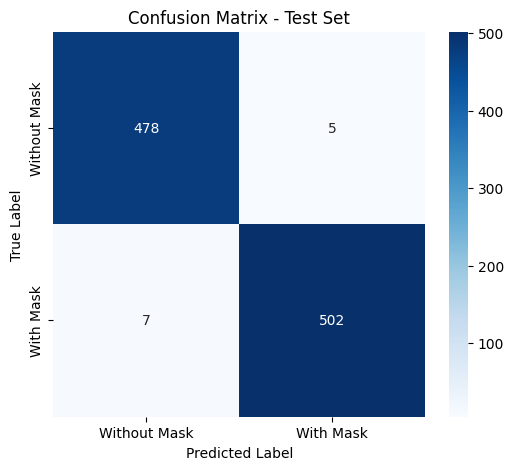

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Without Mask', 'With Mask'],
            yticklabels=['Without Mask', 'With Mask'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig("facemaskcfm")
plt.show()

## Final Prediction Funtion

In [16]:
import cv2

In [20]:
def predict_mask(image_path, model, threshold=0.5):
    # Read the original image
    orig_img = cv2.imread(image_path)
    if orig_img is None:
        print("Error: Could not read image")
        return None, None
    
    # Make a copy for display
    display_img = orig_img.copy()
    
    # Convert to RGB for prediction and display
    rgb_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    
    # Resize for model input
    input_img = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))
    input_img = input_img.astype(np.float32) / 255.0
    input_img = np.expand_dims(input_img, axis=0)
    
    # Make prediction
    pred = model.predict(input_img, verbose=0)[0][0]
    
    if pred < 0.5:
        label = "With Mask"
        confidence = (1 - pred) * 100
        box_color = (0, 255, 0)      # Green
    else:
        label = "Without Mask"
        confidence = pred * 100
        box_color = (0, 0, 255)      # Red
    
    # Draw bounding box around the face (using simple face detection)
    gray = cv2.cvtColor(display_img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    
    for (x, y, w, h) in faces:
        cv2.rectangle(display_img, (x, y), (x+w, y+h), box_color, 3)
        # Put text on image
        text = f"{label} ({confidence:.1f}%)"
        cv2.putText(display_img, text, (x, y-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, box_color, 2)
    
    # If no face detected, still show the whole image with prediction
    if len(faces) == 0:
        h, w = display_img.shape[:2]
        cv2.putText(display_img, f"{label} ({confidence:.1f}%)", 
                    (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, box_color, 3)
    
    # Convert BGR to RGB for matplotlib display
    display_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    
    # Show the image
    plt.figure(figsize=(10, 8))
    plt.imshow(display_rgb)
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    # Also print in console
    print(f"Prediction : {label}")
    print(f"Confidence : {confidence:.2f}%")
    
    return label, confidence

## Predict Here

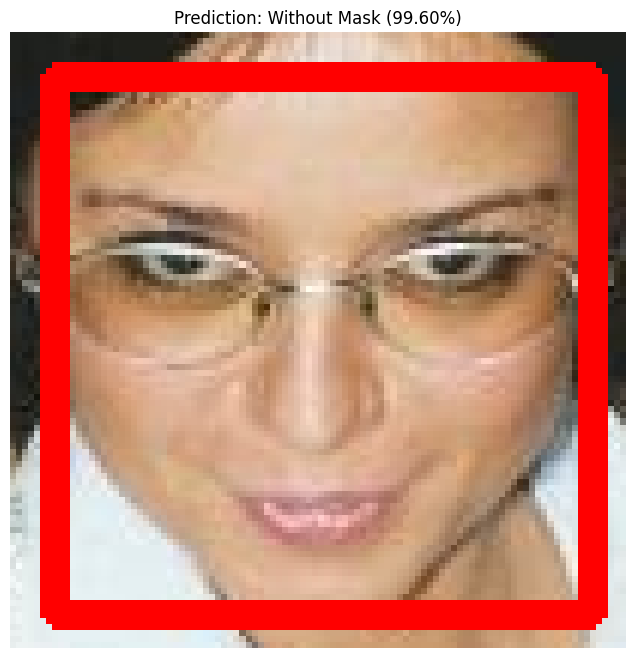

Prediction : Without Mask
Confidence : 99.60%


In [21]:
result = predict_mask('/kaggle/input/datasets/ashishjangra27/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithoutMask/1163.png', model)


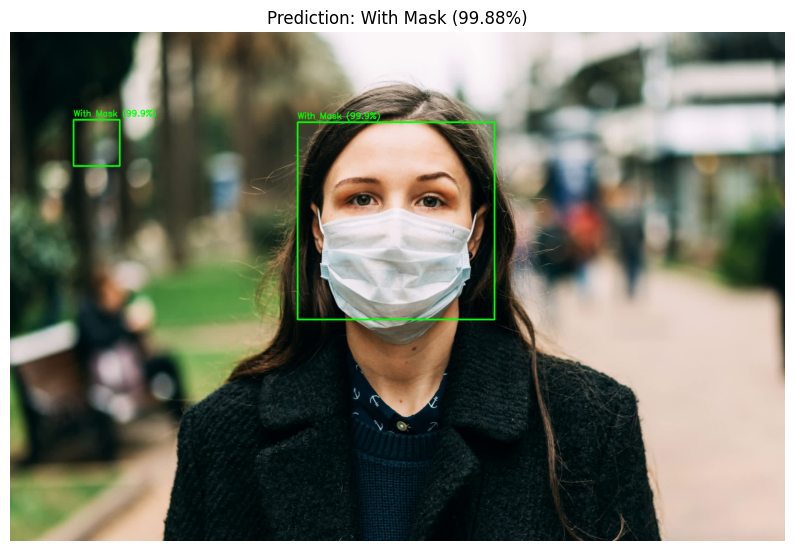

Prediction : With Mask
Confidence : 99.88%


In [23]:
result = predict_mask('/kaggle/input/datasets/salehmuhammdmangrio/testimagesof/mask.jpg', model)

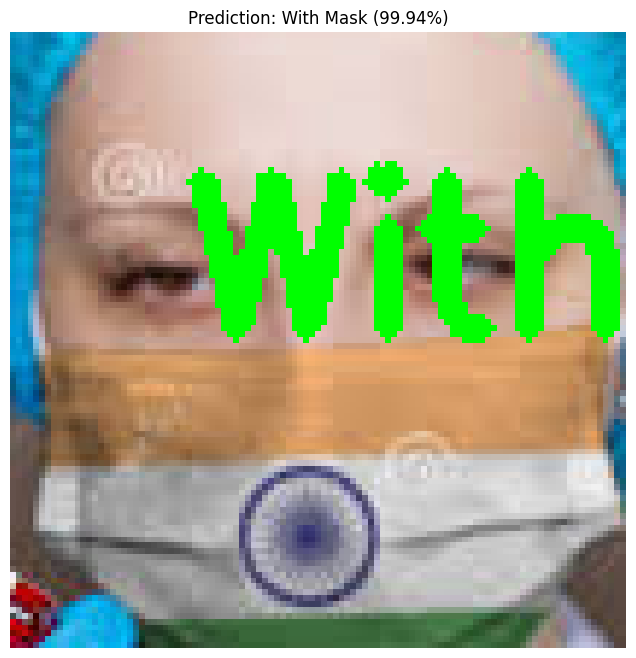

Prediction : With Mask
Confidence : 99.94%


In [24]:
result = predict_mask('/kaggle/input/datasets/ashishjangra27/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithMask/1558.png', model)

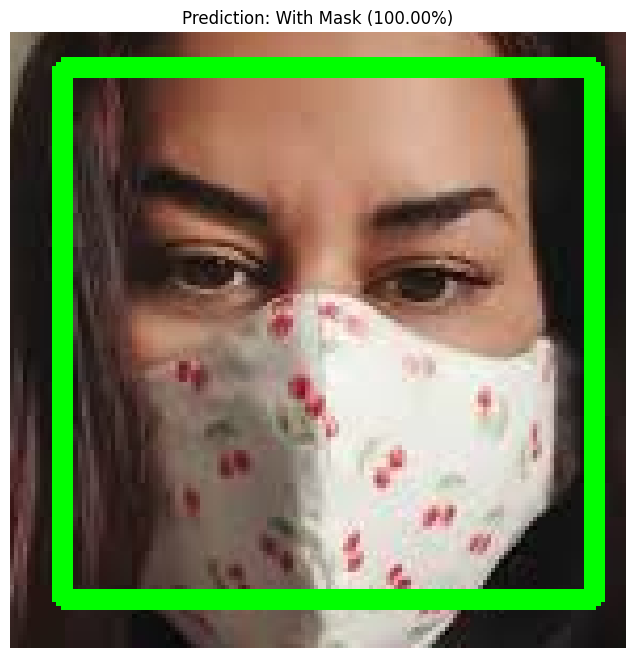

Prediction : With Mask
Confidence : 100.00%


In [25]:
result = predict_mask('/kaggle/input/datasets/ashishjangra27/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithMask/53.png', model)

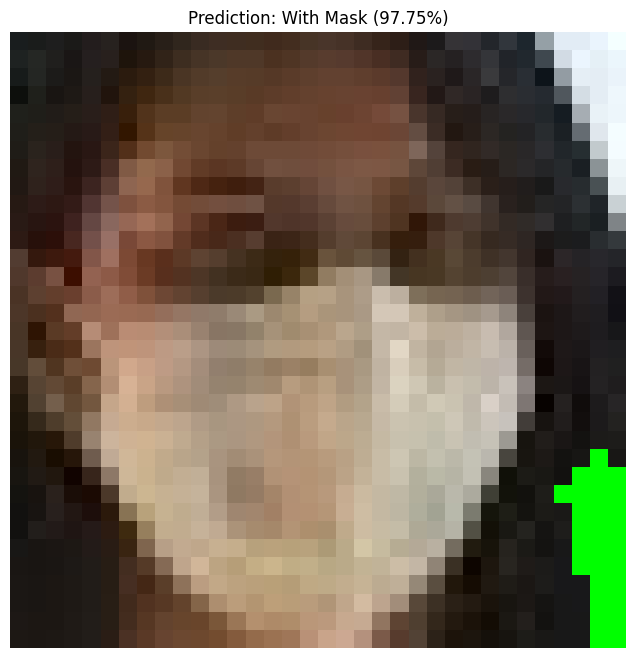

Prediction : With Mask
Confidence : 97.75%


In [26]:
result = predict_mask('/kaggle/input/datasets/ashishjangra27/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithMask/998.png', model)

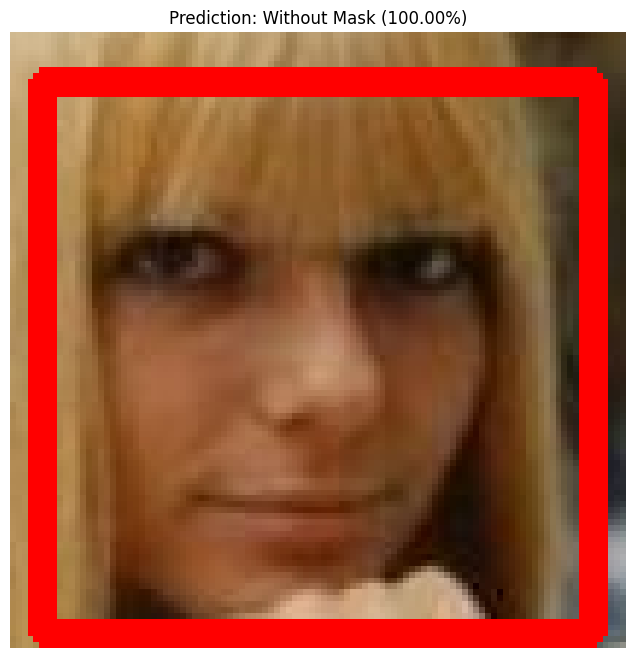

Prediction : Without Mask
Confidence : 100.00%


('Without Mask', np.float32(99.99833))

In [27]:
predict_mask("/kaggle/input/datasets/ashishjangra27/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithoutMask/1639.png",model)